In [123]:
import numpy as np
import matplotlib.pyplot as plt
from kl_tools.emission import LINE_LAMBDAS
import os
print(LINE_LAMBDAS["Ha"])
from scipy.stats import binned_statistic_2d
from astropy import cosmology
import astropy.units as u
from astropy import constants as const
import kl_tools.tngsim as tngsim
import kl_tools.grism_modules.grism as grism
import kl_tools.priors as priors
import kltools_grism_module_2 as m

def get_PA(img, scale, min_r = 10, max_r=30):
    """Estimate the position angle of the major axis of the 2D image using moments."""
    y, x = np.indices(img.shape) * scale
    total = np.sum(img)
    x_centroid = np.sum(x * img) / total
    y_centroid = np.sum(y * img) / total

    x_diff = x - x_centroid
    y_diff = y - y_centroid
    r_diff = np.sqrt(x_diff**2 + y_diff**2)
    print(r_diff.max())
    weight = img * (r_diff >= min_r) * (r_diff <= max_r)

    Ixx = np.sum(weight * x_diff**2) / total
    Iyy = np.sum(weight * y_diff**2) / total
    Ixy = np.sum(weight * x_diff * y_diff) / total

    theta = 0.5 * np.arctan2(2 * Ixy, Ixx - Iyy)
    PA = np.degrees(theta) % 180  # Position angle in degrees [0, 180)
    return PA

6564.589 Angstrom


# Generating Mock Roman Observation of TNG Galaxies

This notebook aims at generating mock broadband image and grism spectra for simulated disk galaxies in TNG, assume Roman specs.

## 1. Loading Mock Galaxy Data


In [124]:
TNG_mock_data_dir = "/xdisk/timeifler/jiachuanxu/KL_TNG_Mock/Mocks"

stellar_data = np.load(os.path.join(TNG_mock_data_dir, "stellar_data_analysis.npz"), allow_pickle=True)['arr_0']
gas_data = np.load(os.path.join(TNG_mock_data_dir, "gas_data_analysis.npz"), allow_pickle=True)['arr_0']
subhalo_data = np.load(os.path.join(TNG_mock_data_dir, "subhalo_data_analysis.npz"), allow_pickle=True)['arr_0']
print("Data loaded successfully.")

print("Gas data keys:", gas_data[0].keys())
print("Dark matter data keys:", subhalo_data[0].keys())
print("Stellar data keys:", stellar_data[0].keys())

Data loaded successfully.
Gas data keys: dict_keys(['NeutralHydrogenAbundance', 'Velocities', 'Coordinates', 'GFM_Metals', 'Density', 'GFM_Metallicity', 'ElectronAbundance', 'StarFormationRate', 'Masses', 'Temperature'])
Dark matter data keys: dict_keys(['SubhaloID', 'SnapNum', 'SubhaloMass', 'SubhaloStellarMass', 'SubhaloGasMass', 'SubhaloDMMass', 'SubhaloBaryonicMass', 'GasToStellarMassRatio', 'SubhaloPos', 'SubhaloPosX', 'SubhaloPosY', 'SubhaloPosZ', 'DistanceMpc', 'DistanceModulus', 'SubhaloVel', 'SubhaloVelX', 'SubhaloVelY', 'SubhaloVelZ', 'VelocityMagnitude', 'SubhaloSFR', 'SubhaloGasMetallicity', 'SubhaloStellarMetallicity', 'SubhaloHalfmassRad', 'SubhaloHalfmassRadStars', 'SubhaloHalfmassRadGas', 'SubhaloHalfmassRadDM', 'SubhaloMaxCircVel', 'SubhaloVelDisp', 'SpecificSFR', 'SurfaceDensity', 'SubhaloMassType', 'SubhaloSpin', 'SubhaloFlag', 'Redshift', 'LookbackTime', 'CosmicTime', 'BarSize', 'BarStrength', 'Barred', 'Bulge', 'Halo', 'PseudoBulge', 'QualityFlags', 'StellarMass', 

In [134]:
for k in stellar_data[0].keys():
    print(k)

GFM_Metallicity
Velocities
GFM_StellarFormationTime
Coordinates
Masses
Stellar_age
AB_apparent_magnitude_r
Raw_Luminosity_r
Dusted_Luminosity_r
AB_apparent_magnitude_u
Raw_Luminosity_u
Dusted_Luminosity_u
AB_apparent_magnitude_z
Raw_Luminosity_z
Dusted_Luminosity_z
AB_apparent_magnitude_g
Raw_Luminosity_g
Dusted_Luminosity_g
AB_apparent_magnitude_i
Raw_Luminosity_i
Dusted_Luminosity_i


# Create Broadband Image and Grism Spectra?


In [126]:


cosmo = cosmology.Planck18
def get_emission_line_flux(gas_data, z=0.6):
    T = gas_data["Temperature"]
    h = cosmo.h # hubble parameter
    dL = cosmo.luminosity_distance(z)

    alpha = 2.6e-13 * (T/1e4)**(-0.7)  * u.cm**3 / u.s
    Xe = gas_data['ElectronAbundance'][:]
    XH = 0.76
    density = gas_data['Density'][:]*u.Msun/u.kpc**3
    nH =  (XH * density / const.m_p).to(1/u.cm**3)
    ne = Xe * nH
    V = (gas_data['Masses'][:]* u.M_sun) / density
    # print(np.max(V), np.min(V))
    # print(np.max(alpha), np.min(alpha))
    # print(np.max(density), np.min(density))
    # print(np.max(ne), np.min(ne))
    # print(np.max(nH), np.min(nH))
    # Number of recombinations in this volume element
    nr = alpha * ne * nH * V
    #print(nr[0], ne[0], nH[0], V[0], alpha[0])
    # What's the flux from this particle at the observer?
    photon_flux = ( nr / (4 * np.pi * dL**2) ).to(1/u.cm**2/u.s)
    return photon_flux

In [127]:

bins = [64, 64]
subhalo_id = 0
#bins = [128, 128]
dA = (cosmo.angular_diameter_distance(0.6)/u.rad).to(u.kpc/u.arcsec)
pix_scale = 0.065 # arcsec/pix
extent_kpc = pix_scale * dA.value * np.array([-bins[0]/2, bins[0]/2, -bins[1]/2, bins[1]/2])

gasX = gas_data[subhalo_id]["Coordinates"][:,0] - subhalo_data[subhalo_id]["SubhaloPos"][0]
gasY = gas_data[subhalo_id]["Coordinates"][:,1] - subhalo_data[subhalo_id]["SubhaloPos"][1]
starX = stellar_data[subhalo_id]["Coordinates"][:,0] - subhalo_data[subhalo_id]["SubhaloPos"][0]
starY = stellar_data[subhalo_id]["Coordinates"][:,1] - subhalo_data[subhalo_id]["SubhaloPos"][1]
emission_flux = get_emission_line_flux(gas_data[subhalo_id])
vlos = gas_data[subhalo_id]["Velocities"][:,2] - subhalo_data[subhalo_id]["SubhaloVel"][2]

Photon_rate, x_edge, y_edge, binID = binned_statistic_2d(gasX,  gasY,
            emission_flux, statistic=np.sum, bins=bins,
            range=[[extent_kpc[0], extent_kpc[1]], [extent_kpc[2], extent_kpc[3]]]
            )
Nparticle, x_edge, y_edge, binID = binned_statistic_2d(gasX,  gasY,
            emission_flux, statistic=len, bins=bins,
            range=[[extent_kpc[0], extent_kpc[1]], [extent_kpc[2], extent_kpc[3]]]
            )
rband_flux, x_edge, y_edge, binID = binned_statistic_2d(starX, starY,
            stellar_data[subhalo_id]["Dusted_Luminosity_r"], statistic=np.sum, bins=bins,
            range=[[extent_kpc[0], extent_kpc[1]], [extent_kpc[2], extent_kpc[3]]]
            )
StarPart, x_edge, y_edge, binID = binned_statistic_2d(starX,  starY,
            stellar_data[subhalo_id]["Dusted_Luminosity_r"], statistic=len, bins=bins,
            range=[[extent_kpc[0], extent_kpc[1]], [extent_kpc[2], extent_kpc[3]]]
            )
vlos, x_edge, y_edge, binID = binned_statistic_2d(gasX,  gasY,
            vlos, statistic=np.mean, bins=bins,
            range=[[extent_kpc[0], extent_kpc[1]], [extent_kpc[2], extent_kpc[3]]]
            )
Photon_rate[Nparticle<10]=np.min(Photon_rate[Nparticle>=10])
rband_flux[StarPart<10]=np.min(rband_flux[StarPart>=10])
print(np.log10(subhalo_data[subhalo_id]["SubhaloStellarMass"]))


10.571988565523917


In [128]:
np.min(rband_flux[Nparticle>=10])

8.314951094680139e+38

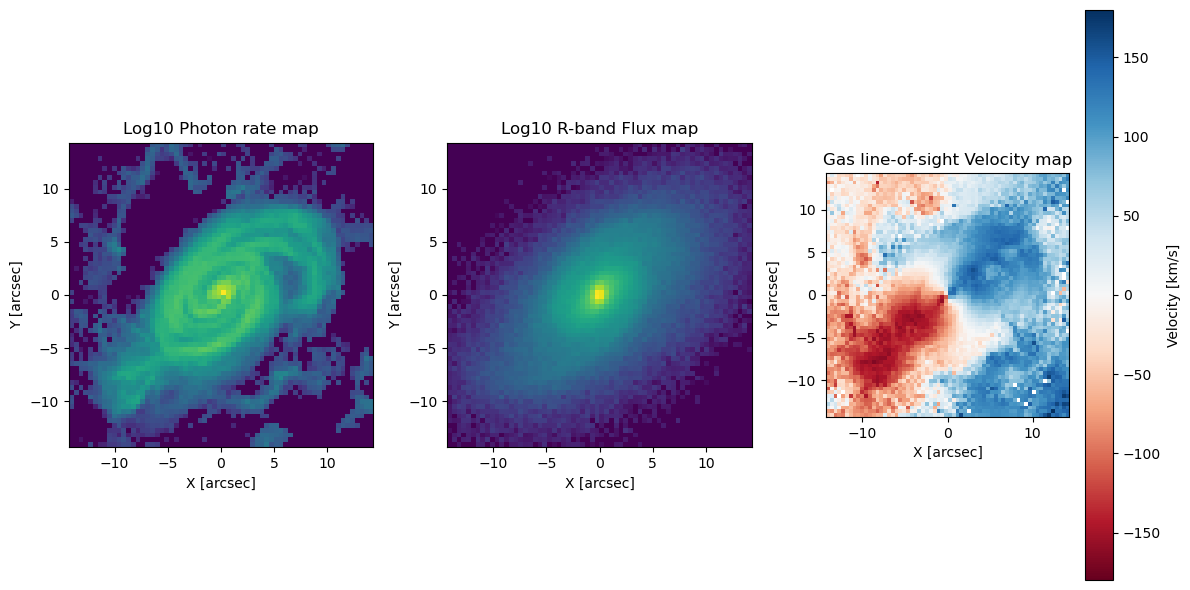

10.571988565523917


In [129]:
fig, axes = plt.subplots(1,3, figsize=(12,6))

axes[0].imshow(np.log10(Photon_rate), 
               origin='lower', extent=extent_kpc)
axes[0].set_title("Log10 Photon rate map")
axes[0].set_xlabel("X [arcsec]")
axes[0].set_ylabel("Y [arcsec]")

axes[1].imshow(np.log10(rband_flux), origin='lower', extent=extent_kpc)
axes[1].set_title("Log10 R-band Flux map")
axes[1].set_xlabel("X [arcsec]")
axes[1].set_ylabel("Y [arcsec]")

cb = axes[2].imshow(-vlos, origin='lower', extent=extent_kpc, cmap='RdBu', 
                    vmin=-180, vmax=180)
axes[2].set_title("Gas line-of-sight Velocity map")
axes[2].set_xlabel("X [arcsec]")
axes[2].set_ylabel("Y [arcsec]")
plt.colorbar(cb, ax=axes[2], label="Velocity [km/s]")

plt.tight_layout()
plt.show()
print(np.log10(subhalo_data[subhalo_id]["SubhaloStellarMass"]))

In [130]:
sim = tngsim.TNGsimulation(init_from_data=True, 
                           data = {'gas': gas_data[0], 
                                   'stars': stellar_data[0], 
                                   'subhalo': subhalo_data[0]})
sim.set_subhalo(0, move_to_redshift = 0.6)

Initializing TNGsimulation from data dictionary.


In [131]:
### Build GrismPars object
### Initialization
meta_pars = {
    'g1': 'sampled',
    'g1': 'sampled',
    'theta_int': 'sampled',
    'sini': 'sampled',
    'units': {
        'v_unit': u.Unit('km/s'),
        'r_unit': u.Unit('arcsec')
        },
    'priors': {
        'g1': priors.GaussPrior(0., 0.1, clip_sigmas=2),
        'g2': priors.GaussPrior(0., 0.1, clip_sigmas=2),
        'theta_int': priors.UniformPrior(-np.pi, np.pi),
        'sini': priors.UniformPrior(0, 1.),
        'v0': priors.GaussPrior(0.0, 30, clip_sigmas=5),
        #'vcirc': priors.UniformPrior(0, 800),
        'vcirc': priors.GaussPrior(300.0, 30, clip_sigmas=5),
        'rscale': priors.UniformPrior(0, 4),
        },
    'velocity': {
        'model': 'default',
        'v0': 'sampled',
        'vcirc': 'sampled',
        'rscale': 'sampled',
    },
    'intensity': {
        # For this test, use truth info
        'type': 'inclined_exp',
        'flux': 1.0, # counts
        'hlr': 0.5,
        },
    # 'marginalize_intensity': True,
    #'psf': gs.Gaussian(fwhm=0.13),
    'run_options': {
        #'remove_continuum': True,
        'use_numba': False
        },
    'model_dimension':{
        'Nx': 150,
        'Ny': 150,
        'scale': 0.0325, # arcsec
        #'lambda_range': [1236.6, 1325.1], # 1190-1370
        #'lambda_range': [[996,1760],],
        'lambda_range': [[1012.8,1088.08],],
        'lambda_res': 0.2, # nm
        'lambda_unit': 'nm',
        'lblue': 800.0,
        'lred': 2000.0,
    },
    'sed':{
        'template': '../data/Simulation/GSB2.spec',
        'wave_type': 'Ang',
        'flux_type': 'flambda',
        #'z': 0.9513,
        #'z': 1.3,
        'z': 0.6,
        'spectral_range': [800., 2000.], # nm
        # obs-frame continuum normalization (nm, erg/s/cm2/nm)
        'obs_cont_norm': [656.3*1.6, 0],
        # a dict of line names and obs-frame flux values (erg/s/cm2)
        'lines':{
            #'O2': [1.0e-16, 1.2e-16],
            #'Hb': 0.8e-16,
            #'O3_1': 1.0e-16,
            #'O3_2': 1.2e-16,
            #'N2_1': 0.2e-16,
            'Ha': 1.5e-16,
            #'N2_2': 0.1e-16,
        },
        # intrinsic linewidth in nm
        'line_sigma_int':{
            #'O2': [0.1, 0.1],
            #'Hb': 0.1,
            #'O3_1': 0.1,
            #'O3_2': 0.1,
            #'N2_1': 0.1,
            'Ha': 0.1,
            #'N2_2': 0.1,
        },
    },
    # observation configuration dict
    'obs_conf': {
        'OBSINDEX': 0,
        'INSTNAME': "HST/WCF3",
        'OBSTYPE': 2,
        'BANDPASS': "../../data/Bandpass/Roman/WFI_Grism_1stOrder.dat",
        'NAXIS': 2,
        #'NAXIS1': 380,# Nx 
        'NAXIS1': 64*3,
        'NAXIS2': 64,# Ny
        'PIXSCALE': 0.055,
        'RSPEC': 461*2,
        'PSFTYPE': "airy_mean",
        'PSFFWHM': 0.13,
        'DISPANG': np.pi/2. * 0.0,
        'OFFSET': -550.96322,
        'DIAMETER': 240.0,
        'EXPTIME': 500,
        'GAIN': 1.0,
        'NOISETYP': 'ccd',
        'SKYLEVEL': 0.1,
        'RDNOISE': 20,
        'ADDNOISE': False,
    },
}
#mid_lambda = np.mean(meta_pars['model_dimension']['lambda_range'])
Ha_cen = 656.28 * (1 + meta_pars['sed']['z']) # nm
meta_pars['obs_conf']['OFFSET'] = -(Ha_cen*meta_pars['obs_conf']['RSPEC']/500)
print(meta_pars['obs_conf']['OFFSET'])
Gpars = grism.GrismPars(meta_pars)
m.clear_observation()
grism.initialize_observations(1, [Gpars], None, overwrite=True)

_cube = sim._generateGrismCube(pars=Gpars, rescale=1.0, method=2, gas_weight=10, cached=True)

grism_img, grism_noise = sim.to_grism(Gpars, rescale=1.0, method=2, gas_weight=10, cached=True)

-1936.288512
>>> set_disperse_helper:
--- OBSTYPE = 2
--- MDNAXIS1 = 150
--- MDNAXIS2 = 150
--- MDNAXIS3 = 377
--- MDSCALE = 0.0325
--- NAXIS1 = 192
--- NAXIS2 = 64
--- PIXSCALE = 0.055
--- DIAMETER = 240
--- EXPTIME = 500
--- GAIN = 1
--- RSPEC = 922
--- DISPANG= 0
--- OFFSET = -1936.29
[0/1] Setting pixel response table
[0/1] Theory model cube:
	scale = 0.0325	dimension = (Nlam=377, Nx=150, Ny=150)
[0/1] Dispersed image dimension:
	scale = 0.055	dimension = (Ny=64, Nx=192)
[0/1] Pixel res. table size = 14986269
[0/1] 1 observations in this list
Generating 3d data cube
Generating simulated grism image


/tmp/ipykernel_427120/2338846001.py:69: RuntimeWarning: invalid value encountered in log10
  axes[1,2].imshow(np.log10(grism_img-cont_estimate)[:,64:128], origin='lower',


2.4693614987140093
2.479124400490495
PA of Halpha flux map: 48.90 deg
PA of grism image: 59.25 deg


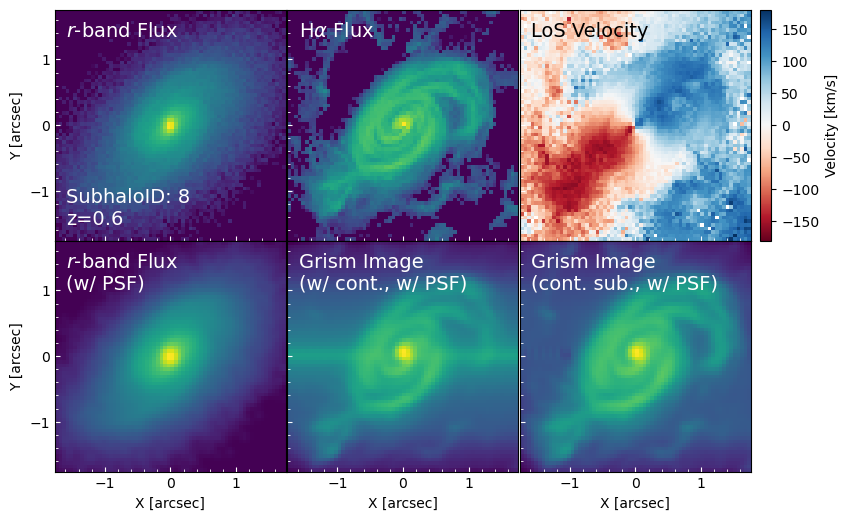

In [133]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MultipleLocator 
import galsim as gs
from scipy.ndimage import gaussian_filter

fig, axes = plt.subplots(2,3, figsize=(9,6))

pix_scale = 0.055 # arcsec/pix
Nx, Ny = rband_flux.shape[1], rband_flux.shape[0]
extent = pix_scale * np.array([-Nx/2, Nx/2, -Ny/2, Ny/2])

### 1. r-band image
axes[0,0].imshow(np.log10(rband_flux), origin='lower', extent=extent)
axes[0,0].text(0.05, 0.95, "$r$-band Flux", color='white', transform=axes[0,0].transAxes,
               fontsize=14, va='top', ha='left')
axes[0,0].text(0.05,0.05, f'SubhaloID: {subhalo_data[0]["SubhaloID"]}\nz={meta_pars["sed"]["z"]}',
               color='white', transform=axes[0,0].transAxes,
               fontsize=14, va='bottom', ha='left')
axes[0,0].set_xlabel("X [arcsec]")
# set the x and y ticks inside
axes[0,0].tick_params(axis='both', which='both', direction='in', color='white')
axes[0,0].set_ylabel("Y [arcsec]")

### 2. Photon rate map
axes[0,1].imshow(np.log10(Photon_rate), 
               origin='lower', extent=extent)
axes[0,1].text(0.05, 0.95, "H$\\alpha$ Flux", color='white', transform=axes[0,1].transAxes,
               fontsize=14, va='top', ha='left')
axes[0,1].tick_params(axis='both', which='both', direction='in', color='white')
axes[0,1].set_xticklabels([])
axes[0,1].set_yticklabels([])


### 3. Velocity map
cb = axes[0,2].imshow(-vlos, origin='lower', extent=extent, cmap='RdBu', 
                    vmin=-180, vmax=180)
axes[0,2].text(0.05, 0.95, "LoS Velocity", color='black', transform=axes[0,2].transAxes,
               fontsize=14, va='top', ha='left')
axes[0,2].tick_params(axis='both', which='both', direction='in', color='white')
axes[0,2].set_xticklabels([])
axes[0,2].set_yticklabels([])

### 4. PSF-convolved r-band image
# Convolve with a Gaussian kernel (sigma=3 pixels)
smoothed_array = gaussian_filter(rband_flux, sigma=0.13/0.055/2.355)
axes[1,0].imshow(np.log(smoothed_array), origin='lower', extent=extent)
axes[1,0].set_ylabel("Y [arcsec]")
axes[1,0].set_xlabel("X [arcsec]")
axes[1,0].tick_params(axis='both', which='both', direction='in', color='white')
axes[1,0].text(0.05, 0.95, "$r$-band Flux\n(w/ PSF)", color='white', 
               transform=axes[1,0].transAxes,
               fontsize=14, va='top', ha='left')

### 5. Grism image (with continuum)
axes[1,1].imshow(np.log10(grism_img[:,64:128]), origin='lower', extent=extent)
axes[1,1].text(0.05, 0.95, "Grism Image\n(w/ cont., w/ PSF)", color='white', 
               transform=axes[1,1].transAxes,
               fontsize=14, va='top', ha='left')
axes[1,1].set_yticklabels([])
axes[1,1].set_xlabel("X [arcsec]")
axes[1,1].tick_params(axis='both', which='both', direction='in', color='white')

### 6. Grism image (continuum subtracted)
### continuum estimation
cont_left = np.median(grism_img[:,30:50], axis=1)
cont_right = np.median(grism_img[:,145:165], axis=1)
cont_estimate = cont_left[:,np.newaxis] + (cont_right - cont_left)[:,np.newaxis] * \
    (np.arange(grism_img.shape[1])[np.newaxis,:]-40)/115
axes[1,2].imshow(np.log10(grism_img-cont_estimate)[:,64:128], origin='lower',
                    extent=extent)
axes[1,2].text(0.05, 0.95, "Grism Image\n(cont. sub., w/ PSF)", color='white', 
               transform=axes[1,2].transAxes,
               fontsize=14, va='top', ha='left')
axes[1,2].set_yticklabels([])
axes[1,2].set_xlabel("X [arcsec]")
axes[1,2].tick_params(axis='both', which='both', direction='in', color='white')

### 
for i in range(2):
    for j in range(3):
        axes[i,j].xaxis.set_major_locator(MultipleLocator(1))
        axes[i,j].yaxis.set_major_locator(MultipleLocator(1))
        axes[i,j].xaxis.set_minor_locator(MultipleLocator(0.2))
        axes[i,j].yaxis.set_minor_locator(MultipleLocator(0.2))

plt.subplots_adjust(hspace=0, wspace=0)

### plot colorbar for velocity map
pos = axes[0,2].get_position()
cax = fig.add_axes([pos.x1 + 0.01, pos.y0, pos.width * 0.05, pos.height])
plt.colorbar(cb, cax=cax, label="Velocity [km/s]", 
fraction=0.046, pad=0.04)

### compare PA of Ha flux and grism image
min_r, max_r = 0.3, 1.0
PA_Ha_truth = get_PA(gaussian_filter(Photon_rate, sigma=0.13/0.055/2.355), 0.055, 
                        min_r=min_r, max_r=max_r)
Pa_Ha_grism = get_PA((grism_img[:,64:128]-cont_estimate[:,64:128]), 0.055,
                        min_r=min_r, max_r=max_r)
print(f"PA of Halpha flux map: {PA_Ha_truth:.2f} deg")
print(f"PA of grism image: {Pa_Ha_grism:.2f} deg")

if False:
    _x = np.linspace(-extent[1], extent[1], 100)
    _y1 = np.tan(np.deg2rad(PA_Ha_truth)) * _x
    _y2 = np.tan(np.deg2rad(Pa_Ha_grism)) * _x
    axes[0,1].plot(_x, _y1, color='cyan', linestyle='--', label='Hα PA')
    axes[0,1].set(xlim=(-extent[1], extent[1]), ylim=(-extent[3], extent[3]))
    axes[1,2].plot(_x, _y1, color='cyan', linestyle='--', label='Hα PA')
    axes[1,2].plot(_x, _y2, color='magenta', linestyle='--', label='Grism PA')
    axes[1,2].legend(loc='lower right', fontsize=10, framealpha=0.5)
    axes[1,2].set(xlim=(-extent[1], extent[1]), ylim=(-extent[3], extent[3]))


#plt.show()
plt.savefig(f"Mock_Roman_Obs_TNG_Subhalo{subhalo_data[0]['SubhaloID']}.png", dpi=300)

(0.0, 0.0003)

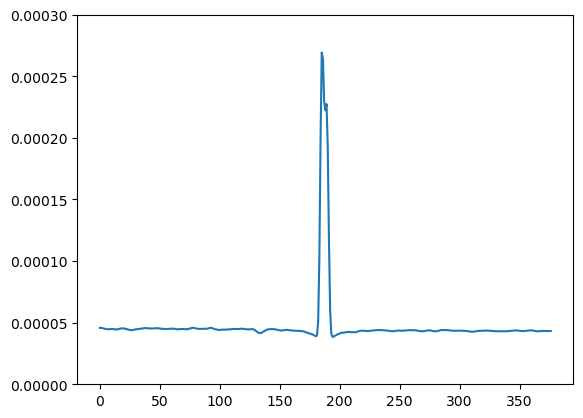

In [35]:
plt.plot(_cube.sum(axis=(1,2)))
plt.ylim(0, 0.0003)

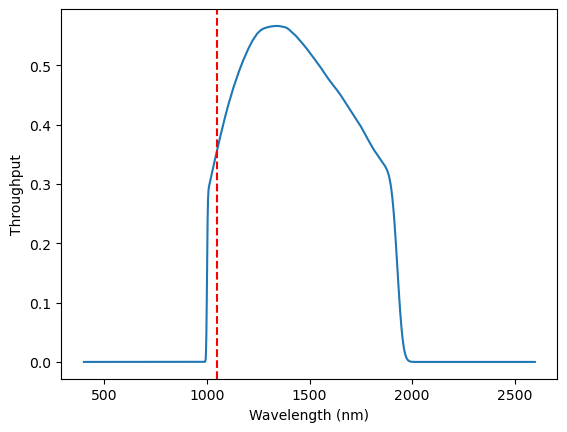

In [22]:
# test_tp = np.genfromtxt("../../data/Bandpass/HST/WFC3_IR_G141_1st.dat")
test_tp = np.genfromtxt("../../data/Bandpass/Roman/WFI_Grism_1stOrder.dat")
plt.plot(test_tp[:,0], test_tp[:,1])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Throughput")
plt.axvline(Ha_cen, color='r', linestyle='--')